# RetinaMNIST Diabetic Retinopathy Classification

In [1]:
!pip install medmnist torchinfo coral-pytorch

## 1. Environment setup and fix random seed

In [2]:
import random
import numpy as np
import os
import hashlib
from matplotlib import pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2
import copy

import torch
from torch import nn
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torchinfo import summary
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, cohen_kappa_score, accuracy_score, confusion_matrix, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

from medmnist import RetinaMNIST

from coral_pytorch.layers import CoralLayer
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch, proba_to_label


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PREPROCESSED_DIR = "/content/preprocessed"

set_seed(SEED)

## 2. Load the dataset

In [3]:
train_dataset = RetinaMNIST(split='train', download=True, size=224)
val_dataset = RetinaMNIST(split='val', download=True, size=224)
test_dataset = RetinaMNIST(split='test', download=True, size=224)

## 3. Data exploration and preprocessing

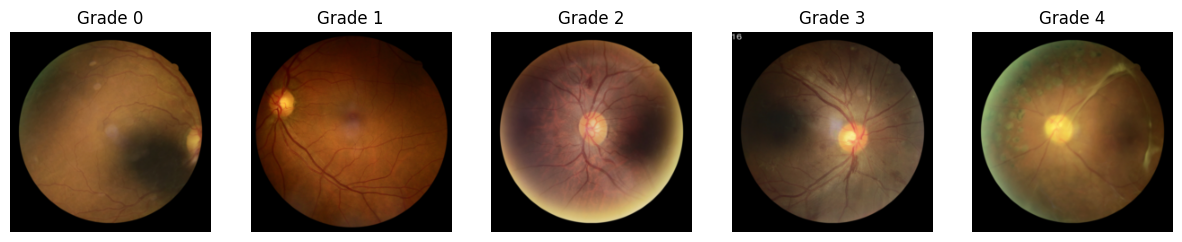

In [4]:
classes = np.unique(train_dataset.labels.flatten())

sample_images = []
for c in classes:
    labels_flat = train_dataset.labels.flatten()
    idx = np.where(labels_flat == c)[0][0]
    img_arr = np.squeeze(train_dataset.imgs[idx])
    sample_images.append(img_arr)

plt.figure(figsize=(15, 5))
for i, img_arr in enumerate(sample_images):
    plt.subplot(1, len(sample_images), i + 1)
    if img_arr.ndim == 3:
        plt.imshow(img_arr)
    else:
        plt.imshow(img_arr, cmap='gray')
    plt.title(f'Grade {int(classes[i])}')
    plt.axis('off')
plt.show()

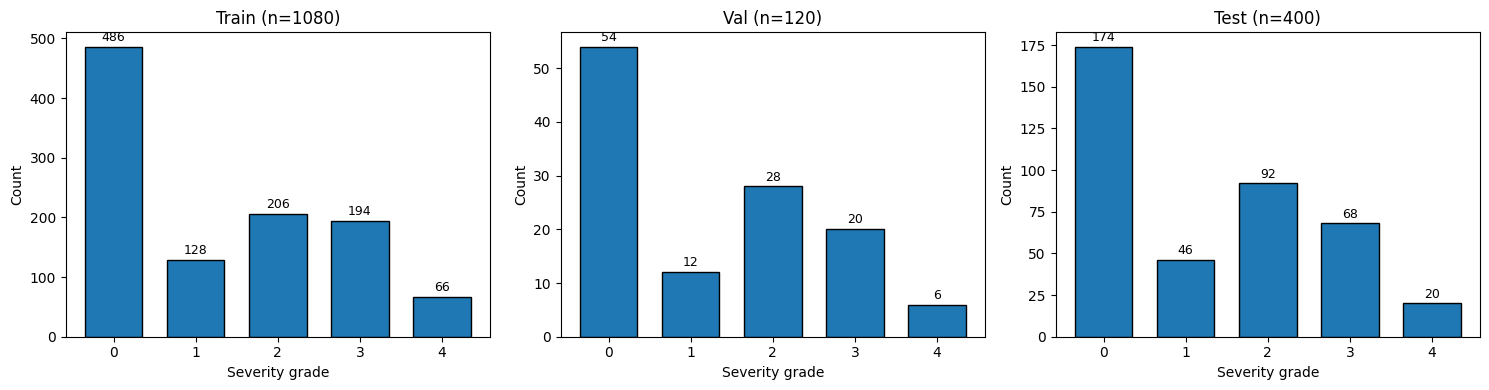

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split_name, dataset in zip(axes,
                                    ['Train', 'Val', 'Test'],
                                    [train_dataset, val_dataset, test_dataset]):
    labels = dataset.labels.flatten()
    counts = np.bincount(labels, minlength=len(classes))
    ax.bar(classes, counts, edgecolor='black', width=0.7)
    ax.set_xticks(classes)
    ax.set_title(f'{split_name} (n={len(labels)})')
    ax.set_xlabel('Severity grade')
    ax.set_ylabel('Count')
    for cls, cnt in zip(classes, counts):
        ax.text(cls, cnt + max(counts) * 0.01, str(cnt),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Check for data leakage across splits

Even if the dataset is well-maintained, we check for duplicates across splits to ensure that there is no data leakage. We compute the MD5 hash of each image and compare them across the training, validation, and test sets. Identical images will have the same hash, so if we find any matching hashes inside and across splits, it indicates that the same image appears multiple times in the same split or in multiple splits, which could lead to data leakage and biased evaluation results.

In [6]:
def md5_hash(img_arr):
    data = img_arr.tobytes()
    return hashlib.md5(data).hexdigest()

train_hashes = [md5_hash(train_dataset.imgs[i]) for i in range(len(train_dataset))]
val_hashes = [md5_hash(val_dataset.imgs[i])   for i in range(len(val_dataset))]
test_hashes = [md5_hash(test_dataset.imgs[i])  for i in range(len(test_dataset))]

train_set = set(train_hashes)
val_set = set(val_hashes)
test_set = set(test_hashes)

print(f"\nSplit sizes:\n\tTrain={len(train_hashes)}\n\tVal={len(val_hashes)}\n\tTest={len(test_hashes)}")
print(f"Unique:\n\tTrain={len(train_set)}\n\tVal={len(val_set)}\n\tTest={len(test_set)}")
print(f"\nIntersections (potential leakage):")
print(f"\tTrain ∩ Val: {len(train_set & val_set)}")
print(f"\tTrain ∩ Test: {len(train_set & test_set)}")
print(f"\tVal ∩ Test: {len(val_set & test_set)}")

for name, h_list in [('Train', train_hashes), ('Val', val_hashes), ('Test', test_hashes)]:
    dup = len(h_list) - len(set(h_list))
    if dup > 0:
        print(f"{name} has {dup} duplicate image(s) within the split")


Split sizes:
	Train=1080
	Val=120
	Test=400
Unique:
	Train=1080
	Val=120
	Test=400

Intersections (potential leakage):
	Train ∩ Val: 0
	Train ∩ Test: 0
	Val ∩ Test: 0


## 4. Preprocessing techniques for diabetic retinopathy

Implementing techniques from the literature:
- **Ben Graham**: Gaussian unsharp masking
- **Usuyama-style**: per-channel normalization

In [7]:
def preprocess_ben_graham(img: np.ndarray, img_size: int = 224, sigma: float = 5)  -> np.ndarray:
    """
    Ben Graham-style preprocessing: resize, apply Gaussian blur, and
    add a circular mask to focus on the central region of the image.
    
    Args:
        img (np.ndarray): Input image.
        img_size (int): Size to which the image is resized (default: 224)
        sigma (float): Standard deviation for Gaussian blur (default: 5)

    Returns:
        np.ndarray: Preprocessed image.

    Reference: used in Graham, B. (2015). Kaggle Diabetic Retinopathy Detection competition.
    """
    img = cv2.resize(img, (img_size, img_size))

    img = cv2.addWeighted(
        img, 4,
        cv2.GaussianBlur(img, (0, 0), sigma), -4,
        128
    )

    mask = np.zeros_like(img)
    h, w = img.shape[:2]
    cv2.circle(mask, (w // 2, h // 2), int(min(h, w) * 0.45), (1, 1, 1), -1)
    img = img * mask + 128 * (1 - mask)

    return np.clip(img, 0, 255).astype(np.uint8)

def preprocess_usuyama(img: np.ndarray, target_size: int = 224) -> np.ndarray:
    """
    Usuyama-style preprocessing: resize, per-channel z-score normalization, and rescale to [0, 255].

    Args:
        img (np.ndarray): Input image.
        target_size (int): Size to which the image is resized (default: 224)

    Returns:
        np.ndarray: Preprocessed image.

    Reference: used in Minarno et al., JOIV 2022
    """
    resized = cv2.resize(img, (target_size, target_size)).astype(np.float32)

    for ch in range(3):
        ch_data = resized[:, :, ch]
        m, s = ch_data.mean(), ch_data.std()
        if s > 0:
            resized[:, :, ch] = (ch_data - m) / s
        else:
            resized[:, :, ch] = ch_data - m

    resized = resized - resized.min()
    resized = (resized / (resized.max() + 1e-8) * 255).astype(np.uint8)

    # TODO: clahe(?)

    return resized

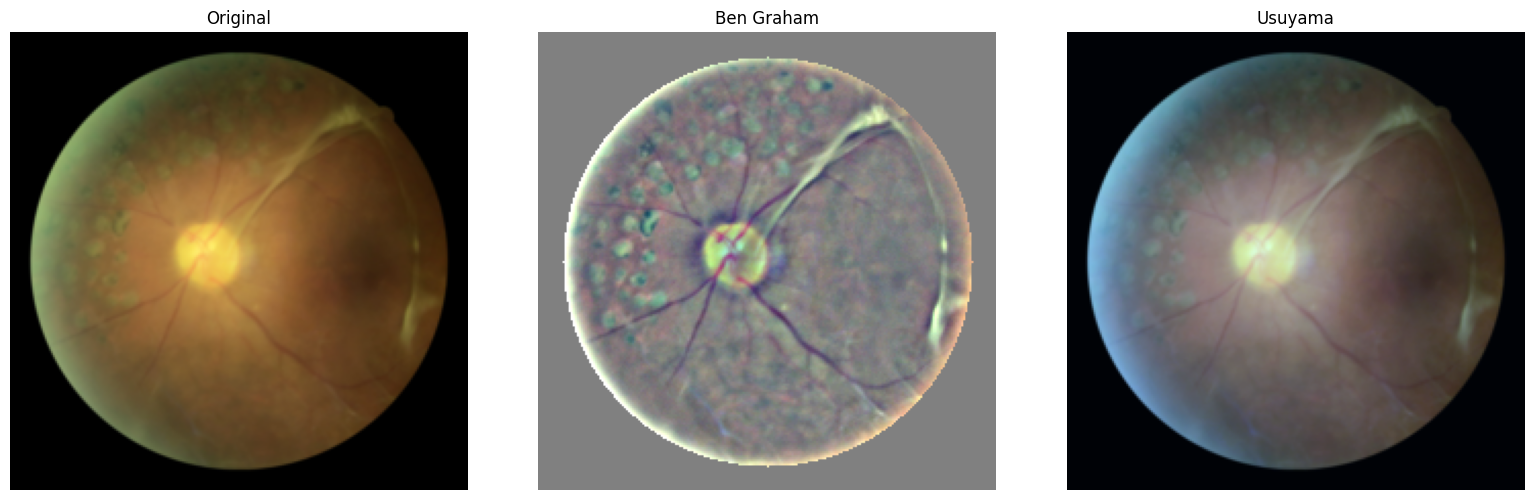

In [8]:
viz_class = 4

labels_flat = train_dataset.labels.flatten()
idx_sample = np.where(labels_flat == viz_class)[0][0]
sample = np.squeeze(train_dataset.imgs[idx_sample]).astype(np.uint8)

original = cv2.resize(sample, (224, 224))
bg = preprocess_ben_graham(sample, sigma=5)
usuyama = preprocess_usuyama(sample)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Original', 'Ben Graham', 'Usuyama']
for ax, img, title in zip(axes, [original, bg, usuyama], titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
splits = [
    ("train", train_dataset),
    ("val",   val_dataset),
    ("test",  test_dataset),
]

for split_name, dataset in splits:
    labels_flat = dataset.labels.flatten()
    class_counts: dict[int, int] = {}
    for i in tqdm(range(len(dataset)), desc=split_name):
        label = int(labels_flat[i])
        class_dir = os.path.join(PREPROCESSED_DIR, split_name, str(label))
        os.makedirs(class_dir, exist_ok=True)

        img = np.squeeze(dataset.imgs[i]).astype(np.uint8)
        proc = preprocess_ben_graham(img)
        # proc = preprocess_usuyama(img)
        # proc = img

        class_counts[label] = class_counts.get(label, 0) + 1
        fname = f"{class_counts[label]:05d}.png"
        Image.fromarray(proc).save(os.path.join(class_dir, fname))

print(f"Images saved under {PREPROCESSED_DIR}/")

test: 100%|██████████| 400/400 [00:10<00:00, 37.69it/s]

Images saved under /content/preprocessed/


In [10]:
def load_preprocessed(split_name: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load saved preprocessed images and labels.
    
    Args:
        split_name (str): Name of the dataset split ('train', 'val', or 'test').
    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing:
            - imgs: A numpy array of shape (N, H, W, C) containing the preprocessed images.
            - labels: A numpy array of shape (N,) containing the corresponding labels for the images.
    """
    split_dir = os.path.join(PREPROCESSED_DIR, split_name)
    imgs, labels = [], []
    class_dirs = sorted(os.listdir(split_dir))
    for cls_dir in class_dirs:
        cls = int(cls_dir)
        img_folder = os.path.join(split_dir, cls_dir)
        for fname in sorted(os.listdir(img_folder), key=lambda x: int(x.split(".")[0])):
            fpath = os.path.join(img_folder, fname)
            img = cv2.imread(fpath)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            imgs.append(img)
            labels.append(cls)
    return np.stack(imgs), np.array(labels)

train_proc_imgs, train_proc_labels = load_preprocessed("train")
val_proc_imgs, val_proc_labels = load_preprocessed("val")
test_proc_imgs, test_proc_labels = load_preprocessed("test")

print(f"Train: {train_proc_imgs.shape} | labels={train_proc_labels.shape}")
print(f"Val: {val_proc_imgs.shape} | labels={val_proc_labels.shape}")
print(f"Test: {test_proc_imgs.shape} | labels={test_proc_labels.shape}")

Train: (1080, 224, 224, 3) | labels=(1080,)
Val: (120, 224, 224, 3) | labels=(120,)
Test: (400, 224, 224, 3) | labels=(400,)


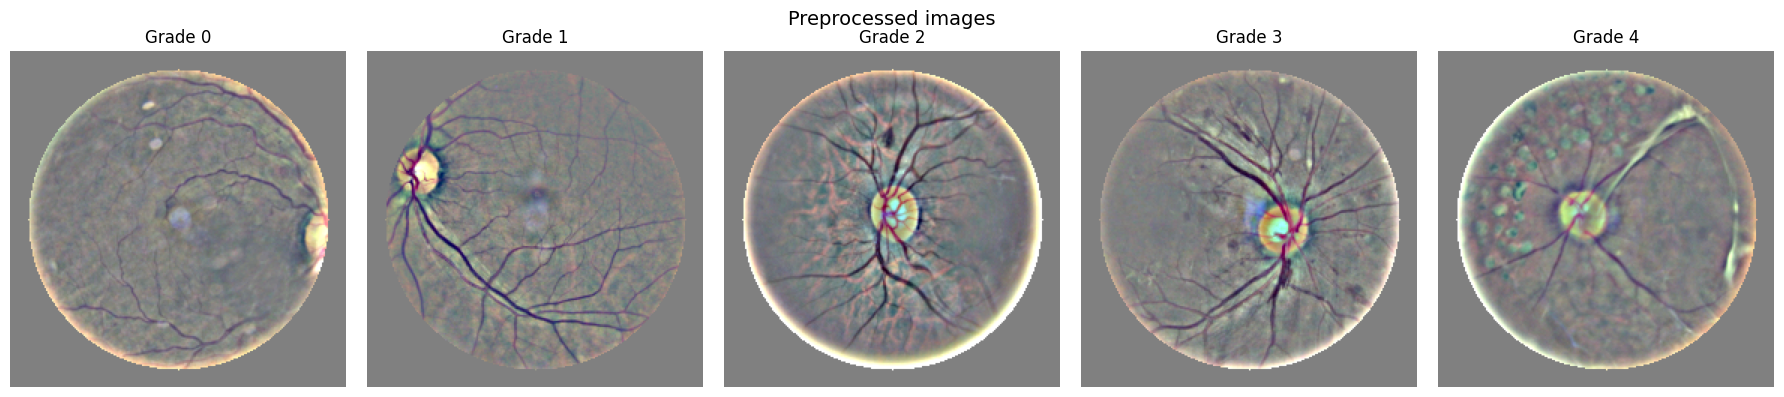

In [11]:
classes = np.unique(train_proc_labels.flatten())
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, cls in enumerate(classes):
    labels_flat = train_proc_labels.flatten()
    sample_idx = np.where(labels_flat == cls)[0][0]
    sample = np.squeeze(train_proc_imgs[sample_idx]).astype(np.uint8)

    axes[idx].imshow(sample)
    axes[idx].set_title(f"Grade {int(cls)}", fontsize=12)
    axes[idx].axis("off")

fig.suptitle("Preprocessed images", fontsize=14)
plt.tight_layout()
plt.show()

Per-channel statistics (preprocessed training set):
 Channel     Mean      Std    Min    Max
       R   130.81    19.77      0    255
       G   129.74    19.15      0    255
       B   129.03    11.60      0    255

Mean (normalized): [0.31081352 0.31081352 0.31081352]
Std  (normalized): [0.1828112  0.1761836  0.15619852]


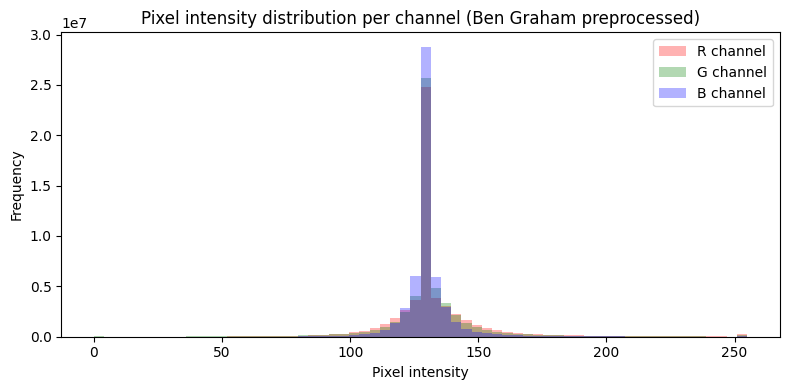

In [12]:
pixels = train_proc_imgs.reshape(-1, 3).astype(np.float32)

print("Per-channel statistics (preprocessed training set):")
print(f"{'Channel':>8} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
for ch, name in enumerate(['R', 'G', 'B']):
    data = pixels[:, ch]
    print(f"{name:>8} {data.mean():>8.2f} {data.std():>8.2f} "
          f"{int(data.min()):>6} {int(data.max()):>6}")

mean = pixels.mean(axis=0) / 255.0
std = pixels.std(axis=0) / 255.0

print(f"\nMean (normalized): {mean}")
print(f"Std  (normalized): {std}")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['red', 'green', 'blue']
for ch, color in enumerate(colors):
    ax.hist(pixels[:, ch], bins=64, color=color, alpha=0.3,
            label=f'{["R","G","B"][ch]} channel')
ax.set_xlabel('Pixel intensity')
ax.set_ylabel('Frequency')
ax.set_title('Pixel intensity distribution per channel (Ben Graham preprocessed)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Data augmentation

To avoid the alteration of features that are clinically important for diagnosis, we apply only simple augmentations, such as **random horizontal and vertical flips**, and **random rotations**. We avoid augmentations that could change the appearance of lesions or other important features, involving colors, brightness, or contrast. We also avoid cropping or resizing that could remove important parts of the retina.

In [13]:
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=20),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

eval_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

train_data = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "train"), transform=train_transforms)
val_data   = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "val"),   transform=eval_transforms)
test_data  = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "test"),  transform=eval_transforms)

print(f"Train: {len(train_data)} samples, classes={train_data.classes}")
print(f"Val:   {len(val_data)} samples,   classes={val_data.classes}")
print(f"Test:  {len(test_data)} samples,  classes={test_data.classes}")

Train: 1080 samples, classes=['0', '1', '2', '3', '4']
Val:   120 samples,   classes=['0', '1', '2', '3', '4']
Test:  400 samples,  classes=['0', '1', '2', '3', '4']


In [ ]:
# TODO: plot 4 augmented images from the training set for a given class (e.g., class 4) to visualize the effect of data augmentation.

## 6. Model architecture

Micro SE Net?

first block:

conv2d 3x3 16 or 32 filters, batch norm relu maxpool

second and third(?) blocks:
conv2d 3x3 32 or 64 filters, batch norm, se block, relu maxpool

adaptive average pooling, flatten, dense 5 units softmax

In [14]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block: channel-wise attention via
    Global Average Pooling + two fully connected layers 
    (reduce (FC1) -> ReLU -> expand (FC2) -> sigmoid).
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class MicroSENet(nn.Module):
    """
    Simple CNN with SE blocks on 224x224 images for 5-class classification.
    Supports both Cross-Entropy (standard Linear head) and CORAL loss (ordinal regression CoralLayer head).

    Architecture:
      Block 1: Conv(3, 32, 3) -> BN -> ReLU -> MaxPool(2) -> Dropout2d(0.1)
      Block 2: Conv(32, 64, 3) -> BN -> ReLU -> SE -> MaxPool(2) -> Dropout2d(0.1)
      Block 3: Conv(64, 128, 3) -> BN -> ReLU -> SE -> MaxPool(2) -> Dropout2d(0.1)
      Block 4: Conv(128, 256, 3) -> BN -> ReLU -> SE -> MaxPool(2) -> Dropout2d(0.1)
      Block 5: Conv(256, 512, 3) -> BN -> ReLU -> SE -> MaxPool(2) -> Dropout2d(0.1)
      Head: AvgPool -> Flatten -> Dropout(0.5) -> Linear(512, num_classes) [CE]
                                                  CoralLayer(512, num_classes) [CORAL]
    """
    def __init__(self, num_classes: int = 5, se_reduction: int = 16, use_coral: bool = False):
        """
        Args:
            num_classes: Number of output classes (default: 5).
            se_reduction: Reduction ratio for SE blocks (default: 16).
            use_coral: If True, replace the final Linear layer with CoralLayer
                       for ordinal regression with CORAL loss.
        """
        super().__init__()
        self.num_classes = num_classes
        self.use_coral = use_coral
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            SEBlock(64, se_reduction),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.1),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            SEBlock(128, se_reduction),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.1),
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            SEBlock(256, se_reduction),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.1),
        )
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            SEBlock(512, se_reduction),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.1),
        )
        if use_coral:
            # CoralLayer outputs (N, K-1) cumulative logits for K classes
            self.head = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Dropout(p=0.5),
                CoralLayer(512, num_classes),
            )
        else:
            self.head = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Dropout(p=0.5),
                nn.Linear(512, num_classes),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.head(x)
        return x

In [15]:
model = MicroSENet(num_classes=5).to(DEVICE)
summary(model, input_size=(1, 3, 224, 224), device=DEVICE)

Layer (type:depth-idx)                   Output Shape              Param #
MicroSENet                               [1, 5]                    --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         864
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 112, 112]         --
│    └─Dropout2d: 2-5                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-6                       [1, 64, 112, 112]         18,432
│    └─BatchNorm2d: 2-7                  [1, 64, 112, 112]         128
│    └─ReLU: 2-8                         [1, 64, 112, 112]         --
│    └─SEBlock: 2-9                      [1, 64, 112, 112]         --
│    │    └─AdaptiveAvgPool2d: 3-1       [1, 64, 1, 1]             --
│    │   

In [16]:
model_coral = MicroSENet(num_classes=5, use_coral=True).to(DEVICE)
summary(model_coral, input_size=(1, 3, 224, 224), device=DEVICE)

Layer (type:depth-idx)                   Output Shape              Param #
MicroSENet                               [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         864
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 112, 112]         --
│    └─Dropout2d: 2-5                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-6                       [1, 64, 112, 112]         18,432
│    └─BatchNorm2d: 2-7                  [1, 64, 112, 112]         128
│    └─ReLU: 2-8                         [1, 64, 112, 112]         --
│    └─SEBlock: 2-9                      [1, 64, 112, 112]         --
│    │    └─AdaptiveAvgPool2d: 3-1       [1, 64, 1, 1]             --
│    │   

## 7. Model training

Pay attention to weight initialization w.r.t. class imbalance.

In [ ]:
def worker_init_fn(worker_id: int) -> None:
    """
    Seed each DataLoader worker deterministically based on its ID.
    
    Args:
        worker_id (int): The ID of the DataLoader worker.
    """
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


torch.use_deterministic_algorithms(True, warn_only=True)

GEN = torch.Generator()
GEN.manual_seed(SEED)


class FolderDataset(Dataset):
    """pytorch Dataset for fold splits: loads images by path with given transform."""
    def __init__(self, paths, targets, transform):
        self.paths = paths
        self.targets = targets
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        target = self.targets[idx]
        if self.transform:
            img = self.transform(img)
        return img, target


all_paths = [p for p, _ in train_data.imgs]
all_targets = np.array(train_data.targets)

### Cross-entropy loss with class weights

In [ ]:
N_FOLDS = 5
EPOCHS = 50
BATCH_SIZE = 32

classes = np.unique(all_targets)
class_weights = compute_class_weight('balanced', classes=classes, y=all_targets)
w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", dict(zip(classes.tolist(), np.round(class_weights, 3))))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_targets)), all_targets), 1):
    print(f"\n{'='*50}\nFold {fold}/{N_FOLDS}\n{'='*50}")

    train_fold = FolderDataset([all_paths[i] for i in train_idx], all_targets[train_idx], train_transforms)
    val_fold   = FolderDataset([all_paths[i] for i in val_idx],   all_targets[val_idx],   eval_transforms)

    train_loader = DataLoader(train_fold, BATCH_SIZE, shuffle=True,
                              worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
    val_loader   = DataLoader(val_fold,   BATCH_SIZE, shuffle=False,
                              worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)

    model = MicroSENet(num_classes=5).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=w)
    val_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_acc, best_state, stale_epochs = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                val_loss += val_criterion(logits, y).item()
                all_preds.extend(logits.argmax(dim=1).cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        val_loss /= len(val_loader)
        all_probs = np.concatenate(all_probs)

        acc = accuracy_score(all_labels, all_preds)
        qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')

        if acc > best_acc:
            best_acc = acc
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        scheduler.step()

        if epoch == 1 or epoch % 5 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Accuracy: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

        if stale_epochs >= 10:
            print(f"  >> Early stopping at epoch {epoch} (no F1 improvement for {stale_epochs} epochs)")
            break

    model.load_state_dict(best_state)

    model.eval()
    best_preds, best_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            best_preds.extend(model(x).argmax(dim=1).cpu().numpy())
            best_labels.extend(y.cpu().numpy())
    best_acc_actual = accuracy_score(best_labels, best_preds)
    best_qwk = cohen_kappa_score(best_labels, best_preds, weights='quadratic')

    fold_results.append(best_acc_actual)
    print(f"\t\tFold {fold} best accuracy: {best_acc_actual:.4f} (QWK: {best_qwk:.4f})")

print(f"\nNested CV Results ({N_FOLDS}-fold):")
print(f"\tAccuracy: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")


Training final model on full training set

Class weights: {0: np.float64(0.444), 1: np.float64(1.688), 2: np.float64(1.049), 3: np.float64(1.113), 4: np.float64(3.273)}
	Epoch  1/50 | LR: 3.00e-04 | Train loss: 1.6091 | Val loss: 1.4273 | Accuracy: 0.4583 | QWK: 0.2266 | AUC: 0.6922
	Epoch  5/50 | LR: 2.93e-04 | Train loss: 1.4734 | Val loss: 1.3262 | Accuracy: 0.5083 | QWK: 0.4933 | AUC: 0.7622
	Epoch 10/50 | LR: 2.71e-04 | Train loss: 1.3849 | Val loss: 1.2670 | Accuracy: 0.5000 | QWK: 0.6021 | AUC: 0.7806
	Epoch 15/50 | LR: 2.38e-04 | Train loss: 1.3426 | Val loss: 1.2554 | Accuracy: 0.5000 | QWK: 0.6426 | AUC: 0.7894
		Early stopping at epoch 18

Validation set results

Macro F1:  0.4196
QWK:       0.6264
Accuracy:  0.5583
AUC:       0.6610

Per-class metrics:
	Grade 0:  precision=0.429  recall=0.870  F1=0.575
	Grade 1:  precision=0.278  recall=0.250  F1=0.263
	Grade 2:  precision=0.496  recall=0.250  F1=0.333
	Grade 3:  precision=0.503  recall=0.350  F1=0.413
	Grade 4:  precision

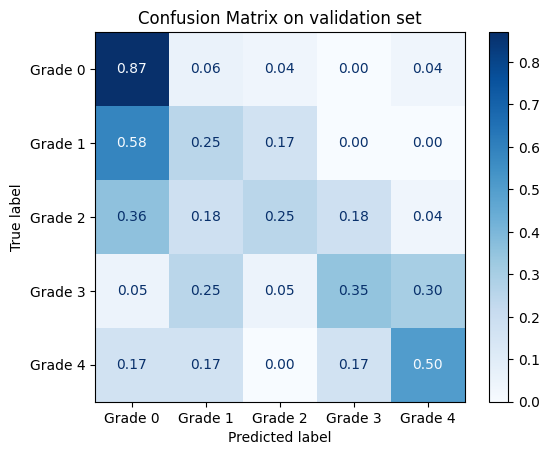

In [ ]:
print(f"\nTraining final model on full training set\n")

EPOCHS = 50
BATCH_SIZE = 32

classes = np.unique(all_targets)
class_weights = compute_class_weight('balanced', classes=classes, y=all_targets)
w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", dict(zip(classes.tolist(), np.round(class_weights, 3))))

final_loader = DataLoader(
    FolderDataset(all_paths, all_targets, train_transforms),
    batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=worker_init_fn, num_workers=2,
)
val_loader  = DataLoader(val_data,  batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)

model_final = MicroSENet(num_classes=5).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=w)
val_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_final.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_acc, best_state, stale_epochs = 0.0, None, 0

for epoch in range(1, EPOCHS + 1):
    model_final.train()
    train_loss = 0.0
    for x, y in final_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_final(x), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(final_loader)

    model_final.eval()
    val_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model_final(x)
            val_loss += val_criterion(logits, y).item()
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    val_loss /= len(val_loader)
    all_probs = np.concatenate(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    if acc > best_acc:
        best_acc = acc
        best_state = copy.deepcopy(model_final.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1

    scheduler.step()

    if epoch == 1 or epoch % 5 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"\tEpoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Accuracy: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

    if stale_epochs >= 10:
        print(f"\t\tEarly stopping at epoch {epoch}")
        break

model_final.load_state_dict(best_state)
model_final.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        val_preds.extend(model_final(x).argmax(dim=1).cpu().numpy())
        val_labels.extend(y.cpu().numpy())

print(f"\nValidation set results\n")
print(f"Macro F1:  {f1_score(val_labels, val_preds, average='macro'):.4f}")
print(f"QWK:       {cohen_kappa_score(val_labels, val_preds, weights='quadratic'):.4f}")
print(f"Accuracy:  {accuracy_score(val_labels, val_preds):.4f}")
print(f"AUC:       {roc_auc_score(val_labels, torch.nn.functional.one_hot(torch.tensor(val_preds), num_classes=5).numpy(), multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(val_labels, val_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"\tGrade {cls}:  precision={prec:.3f}  recall={recall:.3f}  F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix on validation set")
plt.show()

In [ ]:
test_preds, test_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        test_preds.extend(model_final(x).argmax(dim=1).cpu().numpy())
        test_labels.extend(y.cpu().numpy())

print(f"\nTest Set Results\n")
print(f"Macro F1:  {f1_score(test_labels, test_preds, average='macro'):.4f}")
print(f"QWK:       {cohen_kappa_score(test_labels, test_preds, weights='quadratic'):.4f}")
print(f"Accuracy:  {accuracy_score(test_labels, test_preds):.4f}")
print(f"AUC:       {roc_auc_score(test_labels, torch.nn.functional.one_hot(torch.tensor(test_preds), num_classes=5).numpy(), multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(test_labels, test_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"\tGrade {cls}:  precision={prec:.3f}  recall={recall:.3f}  F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix on test set")
plt.show()

In [ ]:
print("CORAL Loss — Nested 5-fold CV (Exp_04)")

N_FOLDS = 5
EPOCHS = 50
BATCH_SIZE = 32

# CORAL importance weights (Cao et al. 2019, Eq.7)
# Per-threshold: upweight imbalanced binary tasks at edges of the distribution
N_CORAL = len(all_targets)
class_counts_coral = np.bincount(all_targets, minlength=5)
cum_pos_coral = np.cumsum(class_counts_coral[::-1])[::-1][1:]  # S_k for k=0..3
M_coral = np.maximum(cum_pos_coral, N_CORAL - cum_pos_coral)
sqrt_M_coral = np.sqrt(M_coral)
coral_importance = torch.tensor(
    sqrt_M_coral / sqrt_M_coral.max(), dtype=torch.float32, device=DEVICE
)
print(f"CORAL importance weights: {coral_importance.cpu().numpy()}")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_targets)), all_targets), 1):
    print(f"\n{'='*50}\nFold {fold}/{N_FOLDS}\n{'='*50}")

    train_fold = FolderDataset([all_paths[i] for i in train_idx], all_targets[train_idx], train_transforms)
    val_fold   = FolderDataset([all_paths[i] for i in val_idx],   all_targets[val_idx],   eval_transforms)

    train_loader = DataLoader(train_fold, BATCH_SIZE, shuffle=True,
                              worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
    val_loader   = DataLoader(val_fold,   BATCH_SIZE, shuffle=False,
                              worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)

    model = MicroSENet(num_classes=5, use_coral=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_acc, best_state, stale_epochs = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            levels = levels_from_labelbatch(y, num_classes=model.num_classes).to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = coral_loss(logits, levels, importance_weights=coral_importance)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                levels = levels_from_labelbatch(y, num_classes=model.num_classes).to(DEVICE)
                val_loss += coral_loss(logits, levels, importance_weights=coral_importance).item()

                probas = torch.sigmoid(logits)
                preds = proba_to_label(probas)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

                # Convert cumulative sigmoid probs -> per-class probs for AUC
                # P(y=0)=1-P(y>0), P(y=k)=P(y>k-1)-P(y>k), P(y=K-1)=P(y>K-2)
                class_probs = torch.cat([
                    1 - probas[:, :1],
                    probas[:, :-1] - probas[:, 1:],
                    probas[:, -1:],
                ], dim=1)
                all_probs.append(class_probs.cpu().numpy())
        val_loss /= len(val_loader)
        all_probs = np.concatenate(all_probs)

        acc = accuracy_score(all_labels, all_preds)
        qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')

        if acc > best_acc:
            best_acc = acc
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        scheduler.step()

        if epoch == 1 or epoch % 5 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Accuracy: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

        if stale_epochs >= 10:
            print(f"  >> Early stopping at epoch {epoch} (no F1 improvement for {stale_epochs} epochs)")
            break

    model.load_state_dict(best_state)
    model.eval()
    best_preds, best_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            best_preds.extend(proba_to_label(torch.sigmoid(model(x))).cpu().numpy())
            best_labels.extend(y.cpu().numpy())

    best_acc_actual = accuracy_score(best_labels, best_preds)
    best_qwk = cohen_kappa_score(best_labels, best_preds, weights='quadratic')
    fold_results.append(best_acc_actual)
    print(f"\t\tFold {fold} best accuracy: {best_acc_actual:.4f} (QWK: {best_qwk:.4f})")

print(f"\nCORAL CV Results ({N_FOLDS}-fold):")
print(f"\tAccuracy: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")

CORAL Loss - Final training on full training set
CORAL importance weights: [0.76537496 0.77815336 0.8992655  1.        ]
	Epoch  1/50 | LR: 3.00e-04 | Train loss: 2.0197 | Val loss: 1.9868 | Accuracy: 0.4167 | QWK: 0.5384 | AUC: 0.7414
	Epoch  5/50 | LR: 2.93e-04 | Train loss: 1.6962 | Val loss: 1.5798 | Accuracy: 0.4750 | QWK: 0.4781 | AUC: 0.7325
	Epoch 10/50 | LR: 2.71e-04 | Train loss: 1.5704 | Val loss: 1.6038 | Accuracy: 0.5083 | QWK: 0.4544 | AUC: 0.7371
	Epoch 15/50 | LR: 2.38e-04 | Train loss: 1.5346 | Val loss: 1.5328 | Accuracy: 0.5000 | QWK: 0.5588 | AUC: 0.7292
	Epoch 20/50 | LR: 1.97e-04 | Train loss: 1.5022 | Val loss: 1.4974 | Accuracy: 0.4917 | QWK: 0.5504 | AUC: 0.7381
		Early stopping at epoch 23
CORAL - Validation set results
Macro F1:  0.3627
QWK:       0.4729
Accuracy:  0.5417
AUC:       0.7437

Per-class metrics:
	Grade 0:  precision=0.302  recall=0.963  F1=0.460
	Grade 1:  precision=0.438  recall=0.083  F1=0.140
	Grade 2:  precision=0.313  recall=0.214  F1=0.254

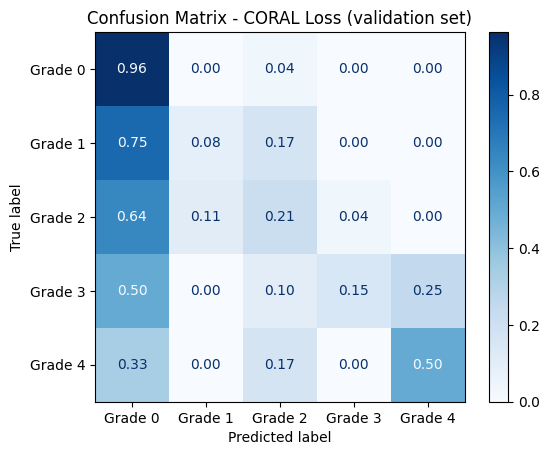

In [ ]:
print(f"CORAL Loss - Final training on full training set")

EPOCHS = 50
BATCH_SIZE = 32

# CORAL importance weights (Cao et al. 2019, Eq.7)
# https://sebastianraschka.com/pdf/papers/2019-coral1-2019-arxiv.pdf

# Per-threshold: upweight imbalanced binary tasks at edges of the distribution
N_CORAL = len(all_targets)
class_counts_coral = np.bincount(all_targets, minlength=5)
cum_pos_coral = np.cumsum(class_counts_coral[::-1])[::-1][1:]  # S_k for k=0..3
M_coral = np.maximum(cum_pos_coral, N_CORAL - cum_pos_coral)
sqrt_M_coral = np.sqrt(M_coral)
coral_importance = torch.tensor(
    sqrt_M_coral / sqrt_M_coral.max(), dtype=torch.float32, device=DEVICE
)
print(f"CORAL importance weights: {coral_importance.cpu().numpy()}")

final_loader = DataLoader(
    FolderDataset(all_paths, all_targets, train_transforms),
    batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=worker_init_fn, num_workers=2,
)
val_loader  = DataLoader(val_data,  batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)

model_final = MicroSENet(num_classes=5, use_coral=True).to(DEVICE)
optimizer = torch.optim.AdamW(model_final.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_acc, best_state, stale_epochs = 0.0, None, 0

for epoch in range(1, EPOCHS + 1):
    model_final.train()
    train_loss = 0.0
    for x, y in final_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        levels = levels_from_labelbatch(y, num_classes=model_final.num_classes).to(DEVICE)
        optimizer.zero_grad()
        logits = model_final(x)
        loss = coral_loss(logits, levels, importance_weights=coral_importance)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(final_loader)

    model_final.eval()
    val_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model_final(x)
            levels = levels_from_labelbatch(y, num_classes=model_final.num_classes).to(DEVICE)
            val_loss += coral_loss(logits, levels, importance_weights=coral_importance).item()

            probas = torch.sigmoid(logits)
            preds = proba_to_label(probas)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            class_probs = torch.cat([
                1 - probas[:, :1],
                probas[:, :-1] - probas[:, 1:],
                probas[:, -1:],
            ], dim=1)
            all_probs.append(class_probs.cpu().numpy())
    val_loss /= len(val_loader)
    all_probs = np.concatenate(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    if acc > best_acc:
        best_acc = acc
        best_state = copy.deepcopy(model_final.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1

    scheduler.step()

    if epoch == 1 or epoch % 5 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"\tEpoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Accuracy: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

    if stale_epochs >= 10:
        print(f"\t\tEarly stopping at epoch {epoch}")
        break

model_final.load_state_dict(best_state)
model_final.eval()

val_preds, val_labels, val_probs = [], [], []
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model_final(x)
        probas = torch.sigmoid(logits)
        preds = proba_to_label(probas)
        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(y.cpu().numpy())

        class_probs = torch.cat([
            1 - probas[:, :1],
            probas[:, :-1] - probas[:, 1:],
            probas[:, -1:],
        ], dim=1)
        val_probs.append(class_probs.cpu().numpy())
val_probs = np.concatenate(val_probs)

print(f"CORAL - Validation set results")
print(f"Macro F1:  {f1_score(val_labels, val_preds, average='macro'):.4f}")
print(f"QWK:       {cohen_kappa_score(val_labels, val_preds, weights='quadratic'):.4f}")
print(f"Accuracy:  {accuracy_score(val_labels, val_preds):.4f}")
print(f"AUC:       {roc_auc_score(val_labels, val_probs, multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(val_labels, val_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"\tGrade {cls}:  precision={prec:.3f}  recall={recall:.3f}  F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix - CORAL Loss (validation set)")
plt.show()

### CORAL loss model test set evaluation

In [ ]:
test_preds, test_labels, test_probs = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model_final(x)
        probas = torch.sigmoid(logits)
        preds = proba_to_label(probas)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(y.cpu().numpy())

        class_probs = torch.cat([
            1 - probas[:, :1],
            probas[:, :-1] - probas[:, 1:],
            probas[:, -1:],
        ], dim=1)
        test_probs.append(class_probs.cpu().numpy())
test_probs = np.concatenate(test_probs)

print(f"CORAL - Test set results")
print(f"Macro F1:  {f1_score(test_labels, test_preds, average='macro'):.4f}")
print(f"QWK:       {cohen_kappa_score(test_labels, test_preds, weights='quadratic'):.4f}")
print(f"Accuracy:  {accuracy_score(test_labels, test_preds):.4f}")
print(f"AUC:       {roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(test_labels, test_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"\tGrade {cls}:  precision={prec:.3f}  recall={recall:.3f}  F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix - CORAL Loss (test set)")
plt.show()

## 8. Out-of-distribution evaluation

## 9. Explaining model predictions (GradCAM++)

## 10. Post-processing techniques

### Temperature scaling